This is my notebook

Place the source link of the dataset you chose:
https://github.com/pyRocksy/Tabular_Data_Analysis_and_ML/tree/main/data/predicting_gym_class_attendance


What is the domain area of the dataset? Describe under which circumstances the data was collected and for which kind of task or purpose:
- The dataset consists of information about gym members and their attendance statistics, which can be helpful for tasks to identify patterns of attendance.



What is the data file structure? Describe here how many files the dataset has, the file format, whether the data includes headers or additional metadata files. Also describe how the data values are separated (e.g., by commas, semicolon, tabs) and how many files you will need to load to access all features from the dataset:
- Its just one csv file with 8 headers and columns, each separated by comma


How many features and how many observations does the dataset have?
- 8 features and 1500 observations.


Does it contain numerical features? Describe the quantity, labels, and if it does not contain numerical features, please find a different dataset where you can conduct numerical analysis.
- Yes. 4 numerical features: months_as_member (discrete), weight (continious), and days_before (discrete).

Does it contain categorical features? Describe how many, the labels, and whether they are ordinal or nominal:
- Yes, day_of_week (ordinal), time (ordinal), category (nominal), and booking_id (nominal).


Does it contain binary features? Describe how many and list their labels. If it does not contain, briefly mention which relevant binary feature may be created/engineered based on the existing numerical or categorical features:
- Yes, one called attended.

-----------------------------------------------------------------

In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
student_name =   "Evgeniia Dolgikh"
student_id =     "evdo4579"
student_background =  "design" # Describe background as [technical, health, design, etc.]

In [6]:
df = pd.read_csv("fitness_class_2212.csv", true_values =["yes"], false_values=["no"])
df.shape

(1500, 8)

In [7]:
df = pd.read_csv("fitness_class_2212.csv", true_values =["yes"], false_values=["no"])
df.head()

,booking_id,months_as_member,weight,days_before,day_of_week,time,category,attended
0,1,17,79.56,8,Wed,PM,Strength,0
1,2,10,79.01,2,Mon,AM,HIIT,0
2,3,16,74.53,14,Sun,AM,Strength,0
3,4,5,86.12,10,Fri,AM,Cycling,0
4,5,15,69.29,8,Thu,AM,HIIT,0


-----------------------------------------------------------------

Propose a data preprocessing pipeline including the necessary steps to produce a clean postprocessed dataset for analysis. The data preparation must include at least: Feature selection, assignation of correct data types, renaming of features and columns for clarity, and management of missing values. Add several text cells (no Python comments) for each step, briefly describe the rationale and thought process on why you are following the chosen pipeline.



Dropping data that is not itended for usage

In [8]:
df.drop("booking_id", axis=1, inplace=True)

Using dropna to clear all empty data

In [9]:
df["months_as_member"] = df["months_as_member"].dropna()

df["weight"] = df["weight"].dropna()

df["days_before"] = df["days_before"].dropna()

df["day_of_week"] = df["day_of_week"].dropna()

df["time"] = df["time"].dropna()

df["category"] = df["category"].dropna()

df["attended"] = df["attended"].dropna()

#clean rows with no data
df.dropna(inplace=True)

In [10]:
# getting total rows with NA values
num_na_rows = df.isna().any(axis=1).sum()
print(f"Number of rows with at least one NA value: {num_na_rows}")

# percentage rows with NA Values
percentage = (num_na_rows / len(df)) * 100
print(f"{percentage:.2f}%")  

Number of rows with at least one NA value: 0
0.00%


translating data to numeric

In [11]:
df['days_before'] = pd.to_numeric(df['days_before'], errors='coerce')

fixing same weekday with different names to be called exactly the same

In [12]:
df["day_of_week"] = df["day_of_week"].replace({"Fri.": "Fri", "Monday": "Mon", "Wednesday": "Wed"})
print(df["day_of_week"].unique())

['Wed' 'Mon' 'Sun' 'Fri' 'Thu' 'Tue' 'Sat']


-----------------------------------------------------------------

Formulate 2 univariate analytical questions that you could answer numerically through conditional filtering. For each question, write the  Python code that provides the answer. Then, reflect on the obtained results (30-50 words). For example, describing whether the result is expected and what it would mean in the context of the whole dataset.

1.How many people attend in the first half of the day and how many in second?

In [13]:
df.groupby(by="time").size().loc["PM"]

np.int64(350)

The results are expected, as now I can clearly see how many people attended after midday. This information can help to plan scheduals and expecting if second part of the day is going to be busy.

-----------------------------------------------------------------

2.What is the mean weight of users?

In [14]:
conditional = df[ ["weight"] ].describe()
print(conditional.loc["mean"])

weight    82.610378
Name: mean, dtype: float64


The result showed the mean of weight of all people in dataset. In the context of whole dataset it would mean that avarage weight equals 82. This information could be used to look on dynamics of peoples avarage weight during some period of time for instance.

-----------------------------------------------------------------

Formulate 2 bivariate analytical questions that you could answer either through pivot tables (groupby). For each question, write the  Python code that provides the answer. Then, reflect on the obtained results (30-50 words).

1.How many months as member each category have?

In [15]:
df.groupby(by=["category"])["months_as_member"].count()

category
-            13
Aqua         74
Cycling     370
HIIT        657
Strength    231
Yoga        135
Name: months_as_member, dtype: int64

The result showed how many months as mmember people are, of each category. In the context of whole dataset it would make possible to see which category is the most popular. In this case HIIT category is the most popular, while Agua is the least. While - means that some members didnt have information about category.

-----------------------------------------------------------------

2.What is the avarge weight of members in category Aqua?

In [16]:
df.groupby(by=["category"])["weight"].mean().loc["Aqua"]

np.float64(81.41432432432433)

The result showed how many months as mmember people are, of each category. In the context of whole dataset it would make possible to see which category is the most popular. In this case HIIT category is the most popular, while Agua is the least. While - means that some members didnt have information about category.

-----------------------------------------------------------------

Formulate 2 bivariate analytical questions that you could answer either through pivot tables (groupby). For each question, write the  Python code that provides the answer. Then, reflect on the obtained results (30-50 words).

1.What is the avarage amount of months as member in category Cycling?

In [17]:
questionOne = df.groupby(by=["category"])["months_as_member"].mean().loc["Cycling"]
print(questionOne) 

15.389189189189189


The results show that average amount of months as member in category cycling is 15. This information is useful to understand for how long members do specificlly cycling. More months means more interest towards category, but at the same time less months could mean that new members are intressted in category.

-----------------------------------------------------------------

2.How does days before change across different days of the week?

In [18]:
attendd = df.groupby(by=["day_of_week"])["days_before"].mean()
print(attendd)



day_of_week
Fri    10.063973
Mon     2.094170
Sat    12.045918
Sun    14.230769
Thu     8.192308
Tue     4.063830
Wed     6.440367
Name: days_before, dtype: float64


Results show the average days before booking depending on the day of the week. The higher the number - the more in advance members book. It seems like towards weekends people book in more days beforу class. Which means that people tend to book earlier for weekend sessions, we can see it in results - sunday 14 days in advance in comparisson to monday 2 days in advance. People plan weekend sessions more ahead, which could be influenced by accesability or limited spots during weekdays when more people are avaivable for sessions

-----------------------------------------------------------------

Formulate 4 bivariate or multivariate analytical questions that you could answer through data visualization. For each question, write the  Python code that provides the answer. Then, reflect on the obtained results (30-50 words), include a brief reflection on whether the selected visualization technique was useful or not.

1.Whats the range of average weight across different categories?

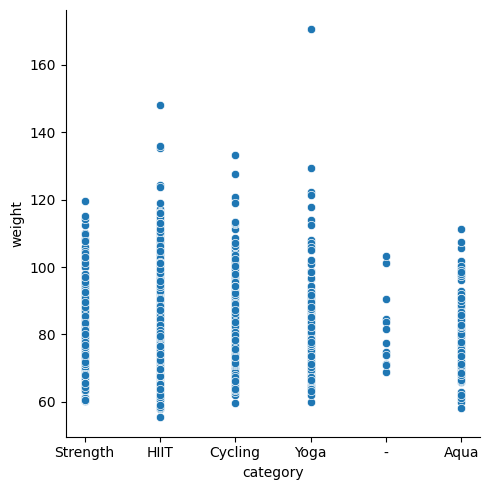

In [19]:
mean_weight = df.groupby(by=["category"])["weight"].mean()

sns.relplot(data=df, x="category", y="weight")

The results show range of average weight across different categories. The vizualization method chosen is not the best to see the results clear. I think choosing bar visualization would work out better, but this method is good for seeing ourliers.

-----------------------------------------------------------------

2.Is there a colleration between day of the week and attendance?

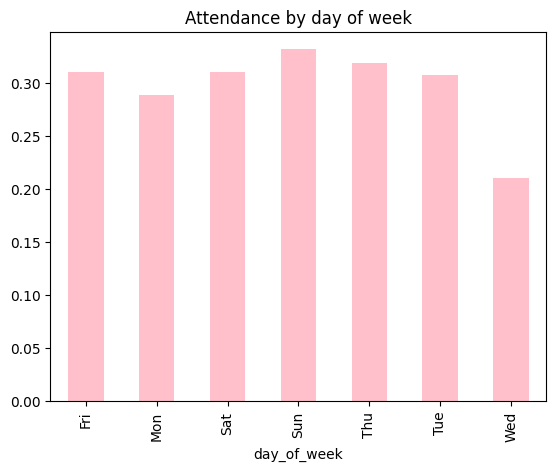

In [20]:
attendance_day = df.groupby("day_of_week")["attended"].mean()

attendance_day.plot.bar(color= "pink")
plt.title("Attendance by day of week") 
plt.show()

Result showed that there are indeed some dependencies on attendance because of day of the week. Friday turned out to be the most attendad day of the week. I see that there are problem with dataset, because some days seem to be displayed multiple times under different name. Information about the most attended day is important to see and analyze, to make predictions of what days are most busy in gym, which can help out in planning and organization. Chosen vizualization tecnique is really useful, as I can see right away the results

2. VERSION 2. Is there a colleration between day of the week and attendance?

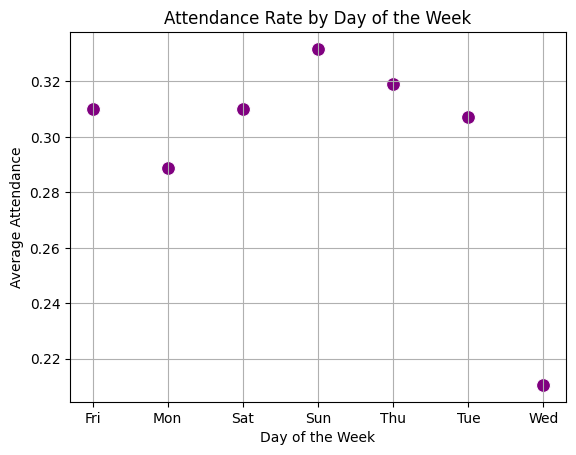

In [21]:
attendance_day = df.groupby("day_of_week")["attended"].mean().reset_index()

sns.scatterplot(data=attendance_day, x="day_of_week", y="attended", color="purple", s=100)
plt.title("Attendance Rate by Day of the Week")
plt.ylabel("Average Attendance")
plt.xlabel("Day of the Week")
plt.grid(True)
plt.show()

I choose to redo this part, to try a more suitable vizualization for the question, so instead of bar i went with scatterplot. It shows the avarage attendance on each day of the week. It seems like sunday is the most visited day, while wednesday is extremly low. I am not sure why the order of weekdays is wrong, but results show that there are correlation between day of the week and attenance. 

-----------------------------------------------------------------

3.Is there a tendancy between months as member and attendance?

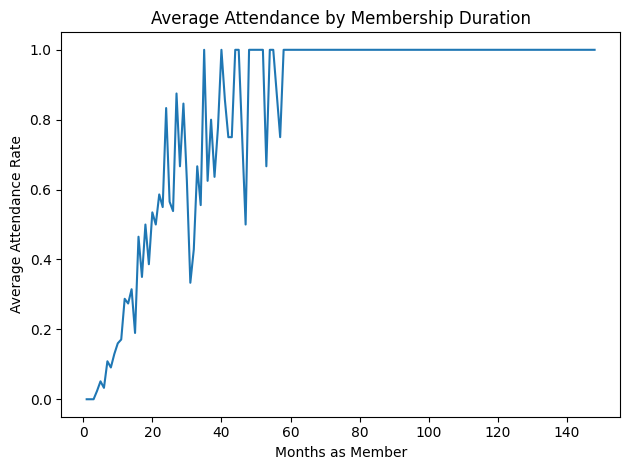

In [22]:
attt = df.groupby("months_as_member")["attended"].mean()
attt.plot.line(title="Average Attendance by Membership Duration")
plt.ylabel("Average Attendance Rate")
plt.xlabel("Months as Member")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Results show a scale of average attendance depending on the months as member. It shows that on average people attend more often when they are members for more months, but there are some drops. This information could be useful for analyzing how consistant peole will attend depending on their membership 

-----------------------------------------------------------------

4. NEW QUESTION: How bookings in advance vary by category?

    (Old question: What category being booked mostly in advance?)

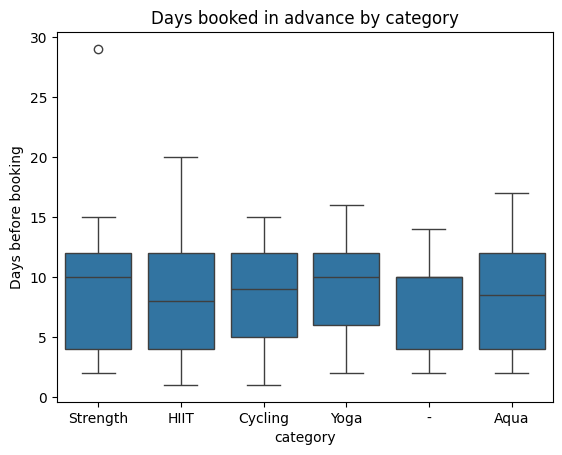

In [23]:
sns.boxplot(x="category", y="days_before", data=df)
plt.title("Days booked in advance by category")
plt.ylabel("Days before booking")
plt.show()

This boxplot type of visualization shows how far in advance people book sessions in each category. This information could be used to analyze how long in advance people book certain activity category. It could be botentially used for understanding how much in advance to send email reminders to members to book certain category in gym. This method of vizualization is good for identifing outliers like strength category is getting booked 29 days in advance which stands out.

-----------------------------------------------------------------

Choose 2 numerical variables from your dataset and calculate the Pearson correlation. Describe the strength and direction of the correlation and reflect on the obtained results (30-50 words).

In [24]:
correlations = df.corr(method="pearson", numeric_only=True)
correlations

,months_as_member,weight,days_before,attended
months_as_member,1.000000,-0.467120,0.002799,0.484441
weight,-0.467120,1.000000,-0.001673,-0.285241
days_before,0.002799,-0.001673,1.000000,0.021673
attended,0.484441,-0.285241,0.021673,1.000000


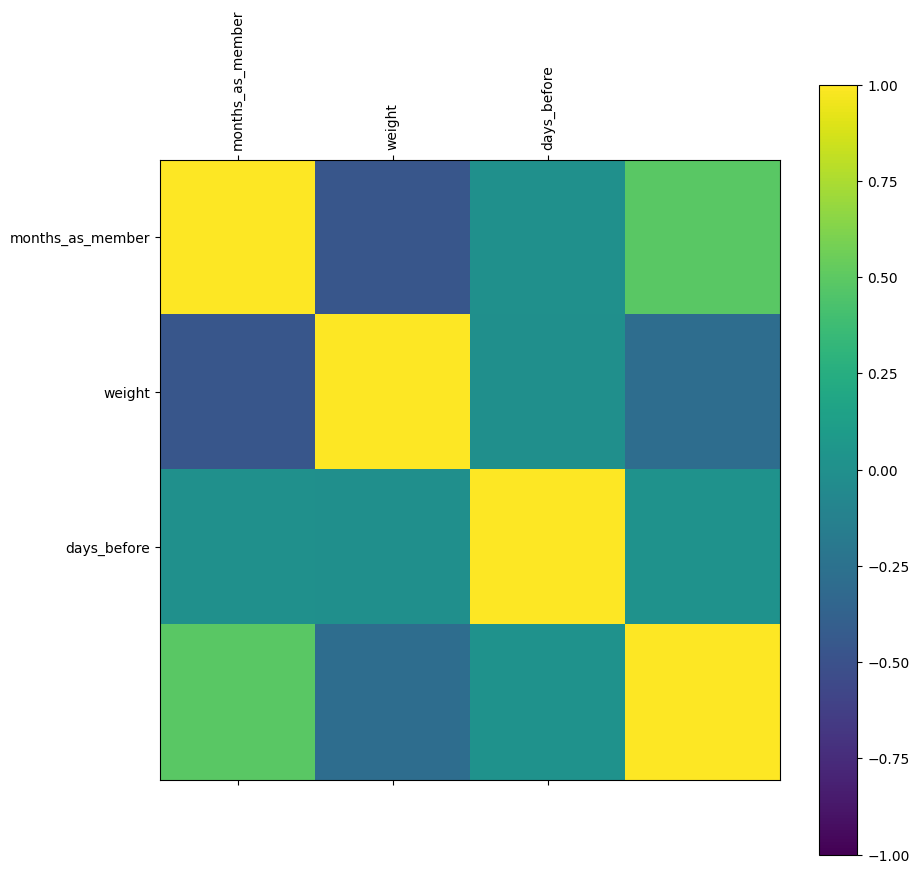

In [25]:
# Plot the correlations visually
fig, ax = plt.subplots(figsize=(10,10))

# Defininig subplots is more flexible and allows
# deeper customization in matplotlib
cax = ax.matshow(correlations, vmin=-1, vmax=1)
fig.colorbar(cax)
axes_labels = df.columns.drop(["category", "attended", "time", "day_of_week"]) # categorical values don't have correlation
plt.xticks(list(range(axes_labels.size)), axes_labels, rotation=90)
plt.yticks(list(range(axes_labels.size)), axes_labels)
plt.show()

As result I got this pearson colleration table. It shows colleration between numerical va;ues seen in table. As reasult we can see that days_before and months_as_member has 0.5 coefficient between them, meaning there is a vague colleration between them. The yellow squeres represent the 1.0, but these are colleration of itself. On other hand weight anf months_as_member show negative correlation -0.5. Everything else eguals 0, meaning there are no colleration between variables. Results show weak colleration, but it may be worth to explore pared variables and their connection further.

-----------------------------------------------------------------

-----------------------------------------------------------------

HOMEWORK 3


Preparing the data for ML classification

1. Choose one feature of your dataset that will serve as a binary target class, and select at least 3 variables that will serve as input features to predict. For the binarization of the target class, there are three alternatives:

    - Choose as target a feature that is already binary in the raw dataset:

        - attended
    
    - 3 variables:

        - days_befpre, category and months_as_member

-----------------------------------------------------------------

2. Reflect on why you chose that input features and the target variable, how you produced the binarization, and frame the prediction task in a sentence (e.g., I will build a model that predicts job from income, education level...) (80-100 words)

    - I choose this features and variable since they are useful for prediction of wether a member will attend session thats booked by using "attend", and then depending on how many days in advance member booked specific session using "days_before" and "category", and also depending on how long person have been a member using "months_as_member".
    Since "attended" is already binary there is no need to do binarization. Also features were choosen since they might impacty behavior regarding attendance, thereefore this model help to predict members attendance behavior based on category of the sessions, booking behavior and how long person have been a member which may point to commitment

-----------------------------------------------------------------

3. Following the last section of the lab "Preparing Categorical features for Classification Tasks". 

    - Apply ordinal encoding and/or one-hot encoding to the categorical variables in your dataset to produce an array that is completely numerical (no text-based values). 
    
    - Show a cell proving that all the data types in your dataset are numerical. 
    
    - Then, write a code to transform the pandas Dataframe into a numpy array, which is the data type expected by ML classifiers in scikit-learn.

In [26]:
X = df[["day_of_week", "category", "months_as_member", "attended"]].dropna()

X

,day_of_week,category,months_as_member,attended
0,Wed,Strength,17,0
1,Mon,HIIT,10,0
2,Sun,Strength,16,0
3,Fri,Cycling,5,0
4,Thu,HIIT,15,0
...,...,...,...,...
1495,Fri,HIIT,21,0
1496,Mon,Strength,29,0
1497,Tue,HIIT,9,0
1498,Sun,Aqua,34,0


In [27]:
# Indicate that the column is an ordered categorical feature
categ = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
X["day_of_week_number"] = pd.Categorical(X["day_of_week"], categories=categ, ordered=True)
print(X.dtypes)

day_of_week             object
category                object
months_as_member         int64
attended                 int64
day_of_week_number    category
dtype: object


In [28]:
# Get the factors and replace with numbers
labels, unique = pd.factorize(X["day_of_week_number"], sort=True)
print(labels, unique)

[2 0 6 ... 1 6 3] CategoricalIndex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], categories=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], ordered=True, dtype='category')


In [29]:
# We can replace the column with the labels
X["day_of_week_number"] = labels
X

,day_of_week,category,months_as_member,attended,day_of_week_number
0,Wed,Strength,17,0,2
1,Mon,HIIT,10,0,0
2,Sun,Strength,16,0,6
3,Fri,Cycling,5,0,4
4,Thu,HIIT,15,0,3
...,...,...,...,...,...
1495,Fri,HIIT,21,0,4
1496,Mon,Strength,29,0,0
1497,Tue,HIIT,9,0,1
1498,Sun,Aqua,34,0,6


In [30]:
# drop original column
X = X.drop(["day_of_week"], axis=1)


oneshot

In [31]:
X["day_of_week_number"].unique()

array([2, 0, 6, 4, 3, 1, 5])

In [32]:
# This function transforms a categorical feature into one-hot encoding
pd.get_dummies(X["category"])

,-,Aqua,Cycling,HIIT,Strength,Yoga
0,False,False,False,False,True,False
1,False,False,False,True,False,False
2,False,False,False,False,True,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
1495,False,False,False,True,False,False
1496,False,False,False,False,True,False
1497,False,False,False,True,False,False
1498,False,True,False,False,False,False


In [33]:
## Replace the column in the dataframe
# Add the new columns after one-hot encoding
oh_encoding = pd.get_dummies(X["category"])
X = pd.concat([X, oh_encoding], axis=1)
X

,category,months_as_member,attended,day_of_week_number,-,Aqua,Cycling,HIIT,Strength,Yoga
0,Strength,17,0,2,False,False,False,False,True,False
1,HIIT,10,0,0,False,False,False,True,False,False
2,Strength,16,0,6,False,False,False,False,True,False
3,Cycling,5,0,4,False,False,True,False,False,False
4,HIIT,15,0,3,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1495,HIIT,21,0,4,False,False,False,True,False,False
1496,Strength,29,0,0,False,False,False,False,True,False
1497,HIIT,9,0,1,False,False,False,True,False,False
1498,Aqua,34,0,6,False,True,False,False,False,False


In [34]:
# Delete the column "blood_type", we don't need it anymore
X = X.drop(["category"], axis=1)
X

,months_as_member,attended,day_of_week_number,-,Aqua,Cycling,HIIT,Strength,Yoga
0,17,0,2,False,False,False,False,True,False
1,10,0,0,False,False,False,True,False,False
2,16,0,6,False,False,False,False,True,False
3,5,0,4,False,False,True,False,False,False
4,15,0,3,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1495,21,0,4,False,False,False,True,False,False
1496,29,0,0,False,False,False,False,True,False
1497,9,0,1,False,False,False,True,False,False
1498,34,0,6,False,True,False,False,False,False


In [35]:
#plt.hist(df, bins=30, color='pink', edgecolor='black')
df.shape

(1480, 7)

-----------------------------------------------------------------

4. Plot a histogram for the target class. Search what class imbalance is. Then, reflect whether your dataset suffers from it and which effects it may have on machine learning classification (30-50 words)

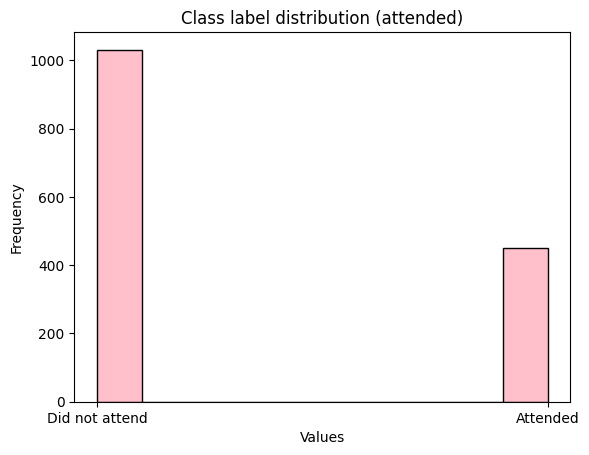

In [36]:
#histogram
plt.hist(X['attended'], color='pink', edgecolor='black')
 
# Adding labels and title
plt.xticks([0, 1], ['Did not attend', 'Attended'])
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Class label distribution (attended)')
 
# Display the plot
plt.show()

The dataset shows feature imbalance, with more people not attending than attending. A classifier will learn with more samples of people not attending, so the predictions can be more biased towards not attending.

-----------------------------------------------------------------

5. Write the code that separates your data into features X and target variable y, respectively. Remember that y should only contain one feature (the binarized target that you want to predict), and X contains the rest of the features that you want to use to predict y.

In [37]:
y = X["attended"]

X = X.drop(columns=["attended"])
X

,months_as_member,day_of_week_number,-,Aqua,Cycling,HIIT,Strength,Yoga
0,17,2,False,False,False,False,True,False
1,10,0,False,False,False,True,False,False
2,16,6,False,False,False,False,True,False
3,5,4,False,False,True,False,False,False
4,15,3,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...
1495,21,4,False,False,False,True,False,False
1496,29,0,False,False,False,False,True,False
1497,9,1,False,False,False,True,False,False
1498,34,6,False,True,False,False,False,False


-----------------------------------------------------------------

6. Search what stratified train-test partitioning means and apply it to your dataset to generate separate your test set from the training data that will be used to build the ML classifier. A common split proportion is a 20% in the test set. Explain what stratified partitioning and the advantages it has in the context of your dataset (30-50 words)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Statified partioning helps to avoid test set with mostly one class by keeping consistent ratio of different classes for training and test sets. Since it showed to be more people that didnt attend this sampling will also prevent bias during evaluation

-----------------------------------------------------------------

Evaluation

1. Following the last section of the lab "Experimental evaluation of classifiers". Create a dictionary with 10 classifiers. Create two variants of the four algorithms seen in class: Decision Tree (DT), Random Forest (RF), K-Nearest Neighbors (KNN), and Support Vector Machine (SVM) algorithms. Then, choose another classifiers from scikit learn (link here), and create two variants. A variant is created by defining different hyperparameters for the same classifier (e.g., KNN with 1 neighbor, and a variant would be KNN with 7 neighbors).

The dataset called `Dataset1` contains 1000 samples and 5 features $\mathbf{X}$, and a binary target variable $\mathbf{y}$.

**Four** different classifiers:

1. `DT` with `max_depth=3`
2. `RF` with `n_estimators=10` and `max_depth=10`
3. `KNN` with `n_neighbors=3`
4. `SVM` with `kernel="rbf"`

**Six** variables of interest:

1. `months_as_member`
2. `weight`
3. `days_before`
4. `day_of_week`
5. `time`
6. `category`

In [39]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [40]:
classifiers = {
    "tree1": DecisionTreeClassifier(max_depth=3),
    "tree2": DecisionTreeClassifier(max_depth=5),
    "RF1": RandomForestClassifier(n_estimators=10, max_depth=5),
    "RF10": RandomForestClassifier(n_estimators=100, max_depth=5),
    "SVM1": Pipeline([
                      ('scaler', MinMaxScaler() ),
                      ('estimator', SVC(kernel='linear') )
                    ]),
    "SVM_rbf": Pipeline([
                      ('scaler', MinMaxScaler() ),
                      ('estimator', SVC(kernel='rbf') )
                    ]),
    "KNN1": Pipeline([
                      ('scaler', MinMaxScaler() ),
                      ('estimator', KNeighborsClassifier(n_neighbors=3) )
                    ]),
    "KNN2": Pipeline([
                      ('scaler', MinMaxScaler() ),
                      ('estimator', KNeighborsClassifier(n_neighbors=7) )
                    ]),
    "LG1": LogisticRegression(max_iter=300),
    "LG10":  LogisticRegression(max_iter=1000),
}

-----------------------------------------------------------------

2. Create an experimental evaluation of the classifiers to try to solve your prediction task. Using cross-validation in the training set. Take the example of the lab to measure: training time, prediction time, accuracy, precision, recall, f1-score.

In [41]:
X_train

,months_as_member,day_of_week_number,-,Aqua,Cycling,HIIT,Strength,Yoga
1158,20,1,False,False,False,True,False,False
464,21,0,False,False,False,True,False,False
407,8,5,False,False,True,False,False,False
964,14,4,False,False,True,False,False,False
1211,38,4,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...
402,15,0,False,False,False,True,False,False
356,18,0,False,False,False,True,False,False
676,2,2,False,False,False,True,False,False
908,17,5,False,False,False,True,False,False


In [42]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
import time
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, clf in classifiers.items():
    acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], []
    train_times, pred_times = [], []

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        t0 = time.time()
        clf.fit(X_tr, y_tr)
        t1 = time.time()

        t2 = time.time()
        y_pred = clf.predict(X_val)
        t3 = time.time()

        acc_scores.append(accuracy_score(y_val, y_pred))
        prec_scores.append(precision_score(y_val, y_pred))
        rec_scores.append(recall_score(y_val, y_pred))
        f1_scores.append(f1_score(y_val, y_pred))

        train_times.append(t1 - t0)
        pred_times.append(t3 - t2)

    results[name] = {
        "accuracy": np.mean(acc_scores),
        "precision": np.mean(prec_scores),
        "recall": np.mean(rec_scores),
        "f1_score": np.mean(f1_scores),
        "train_time": np.mean(train_times),
        "pred_time": np.mean(pred_times)
    }

# Print results
for name, metrics in results.items():
    print(f"\n{name}")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")


tree1
  accuracy: 0.7719
  precision: 0.6800
  recall: 0.4657
  f1_score: 0.5482
  train_time: 0.0012
  pred_time: 0.0008

tree2
  accuracy: 0.7677
  precision: 0.6605
  recall: 0.4908
  f1_score: 0.5607
  train_time: 0.0013
  pred_time: 0.0006

RF1
  accuracy: 0.7652
  precision: 0.6816
  recall: 0.4342
  f1_score: 0.5277
  train_time: 0.0096
  pred_time: 0.0010

RF10
  accuracy: 0.7669
  precision: 0.6693
  recall: 0.4679
  f1_score: 0.5422
  train_time: 0.0843
  pred_time: 0.0051

SVM1
  accuracy: 0.7517
  precision: 0.8267
  recall: 0.2321
  f1_score: 0.3597
  train_time: 0.0083
  pred_time: 0.0024

SVM_rbf
  accuracy: 0.7449
  precision: 0.9004
  recall: 0.1800
  f1_score: 0.2966
  train_time: 0.0116
  pred_time: 0.0086

KNN1
  accuracy: 0.7128
  precision: 0.5336
  recall: 0.4224
  f1_score: 0.4697
  train_time: 0.0024
  pred_time: 0.0071

KNN2
  accuracy: 0.7432
  precision: 0.6111
  recall: 0.4389
  f1_score: 0.5048
  train_time: 0.0019
  pred_time: 0.0074

LG1
  accuracy: 0.7

-----------------------------------------------------------------

3. Iterate on the choices of hyperparameters and classifiers to try to get the best classification performance. When you have decided on final results, calculate the performance of your classifier on the test set put aside from the point 3.6.

In [43]:
best_model = classifiers["RF1"]
best_model.fit(X_train, y_train)
y_test_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
print("Final evaluation on test set:")
print(classification_report(y_test, y_test_pred))

Final evaluation on test set:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       206
           1       0.65      0.49      0.56        90

    accuracy                           0.76       296
   macro avg       0.72      0.69      0.70       296
weighted avg       0.75      0.76      0.75       296



-----------------------------------------------------------------

4. Formulate three analytical questions to assess the results of the evaluation. Include questions about computational efficiency (time) and predictive performance. Reflect/interpret the results of each question (20-30 words).

1. Which classifier achieved the highest f1 score during cross validation?
     - The decision Tree with depth=5 had the best f1 score and showed good balance between precision and recall which is good for this binary attendance prediction task

2. Which model had the shortest prediction time?
     - Decision tree and Logistic Regression were the best witj prediction of time. This is suitable for real time systems

3. Did the classifiers training time vary significantly enough to impact deployment?
     - SVM one and random forest took longer to train, but its performance might justify costs if retraining isnt happening often in the deployment

-----------------------------------------------------------------

5. Which classification model seems to perform better in your data?  Would you deploy it in a real-life task? Why or why not? (30-50 words)

based on the results the random forest with 10 estimators performed best, because they achived highest predictive metrics on cross validation as well as test data. I would probably deploy it in a real life setting, especially if prediction accuracy is prioritized over training speed, but at the same time its longer training time might impact badly some systems